# 4. 딥 러닝의 학습 방법

## 1. 손실 함수(Loss function)

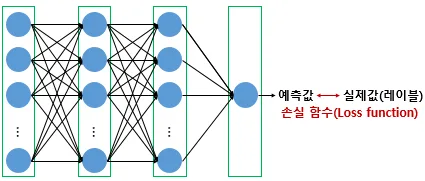

- 실제값과 예측값의 차이를 수치화해주는 함수
- 이 두 값의 차이. 즉, 오차가 클 수록 손실 함수의 값은 크고 오차가 작을 수록 손실 함수의 값은 작아집니다. 회귀에서는 평균 제곱 오차, 분류 문제에서는 크로스 엔트로피를 주로 손실 함수로 사용 
- 손실 함수의 값을 최소화하는 두 개의 매개변수인 가중치 w와
와 편향 b
의 값을 찾는 것이 딥 러닝의 학습 과정이므로 손실 함수의 선정은 매우 중요

### 1) MSE(Mean Squared Error, MSE)

In [13]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

model = Sequential([
    Input(shape=(10,)),
    Dense(64, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import numpy as np

# 샘플 1,000개, 입력 특성 10개
x_train = np.random.rand(1000, 10).astype("float32")

# 샘플마다 정답 1개
y_train = np.random.rand(1000, 1).astype("float32")

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.1258 - mse: 0.1258 - val_loss: 0.1003 - val_mse: 0.1003
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0926 - mse: 0.0926 - val_loss: 0.0834 - val_mse: 0.0834
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0877 - mse: 0.0877 - val_loss: 0.0831 - val_mse: 0.0831
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0862 - mse: 0.0862 - val_loss: 0.0829 - val_mse: 0.0829
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0856 - mse: 0.0856 - val_loss: 0.0820 - val_mse: 0.0820
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0847 - mse: 0.0847 - val_loss: 0.0841 - val_mse: 0.0841
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0841 - mse: 0.0841 - val_loss: 0.0845 - val_mse: 0.0845
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0835 - mse: 0.0835 - val_loss: 0.0819 - val_mse: 0.0819
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.082

In [16]:
print(x_train.shape)  # (1000, 10)
print(y_train.shape)  # (1000, 1)

(1000, 10)
(1000, 1)


In [18]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.2 MB 8.4 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.2 MB 9.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.8 MB/s  0:00:01
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.7 MB 7.6 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/36.7 MB 8.1 MB/s eta 0:00:05
   ----- ---------------------------------- 5.2/36.7 MB 8.2 MB/s eta 0:00:04
   ------- -------------------------------- 6.8/36.7 MB 7.9 MB/s eta 0:00:04
   --------- -----------

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ModuleNotFoundError: No module named 'sklearn'